# ARC-AGI Task Exploration — Human Decision Tree

Browse all 400 training tasks classified by the human-derived decision tree in `scripts/human_tree.py`.

**Sections**
1. Load & classify all tasks  
2. Category summary table  
3. Sample grid — pick any category, see 4 example tasks  
4. Step through a category one task at a time  
5. Inspect any single task in full detail (all train pairs + test input)

In [1]:
import sys
sys.path.insert(0, '..')  # make src/ and scripts/ importable from notebooks/

import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from src.loader import load_all_tasks
from src.visualise import plot_task, plot_category_sample
from scripts.human_tree import classify
from collections import defaultdict

def to_np(task):
    """Return a classify-compatible view of a task with numpy arrays for train grids."""
    return {
        'task_id': task.get('task_id', ''),
        'train': [
            {'input':  np.array(p['input'],  dtype=np.uint8),
             'output': np.array(p['output'], dtype=np.uint8)}
            for p in task['train']
        ]
    }

## 1. Load and classify all training tasks

In [2]:
tasks = load_all_tasks('training')
print(f'Loaded {len(tasks)} tasks')

# Classify every task with the human decision tree
# (classify needs numpy arrays; load_all_tasks returns lists, so we wrap with to_np)
by_tree = defaultdict(list)
for task in tasks:
    cat = classify(to_np(task))
    task['tree_category'] = cat
    by_tree[cat].append(task)

print(f'\nClassified into {len(by_tree)} categories')

Loaded 400 tasks

Classified into 15 categories


## 2. Category summary table

In [3]:
print(f'{"Category":<35} {"Count":>5}  Sample task IDs')
print('-' * 80)
for cat, task_list in sorted(by_tree.items(), key=lambda x: -len(x[1])):
    ids = '  ' + '  '.join(t['task_id'] for t in task_list[:4])
    if len(task_list) > 4:
        ids += ' ...'
    print(f'  {cat:<33} {len(task_list):>5}{ids}')

Category                            Count  Sample task IDs
--------------------------------------------------------------------------------
  MOVE_TO_STATIC                       82  045e512c  05269061  05f2a901  0962bcdd ...
  FILL_REGIONS                         66  00d62c1b  0ca9ddb6  1b60fb0c  2281f1f4 ...
  EXTRACT_UNIQUE_SHAPE                 62  1190e5a7  137eaa0f  1c786137  1cf80156 ...
  COLOUR_BETWEEN_PAIRS                 27  06df4c85  09629e4f  0d3d703e  1e32b0e9 ...
  COLOUR_REMOVAL                       27  1a07d186  1f0c79e5  31aa019c  321b1fc6 ...
  TILE_ASSEMBLY                        20  007bbfb7  10fcaaa3  3af2c5a8  4522001f ...
  ONE_DIM_CROP                         19  0520fde7  1b2d62fb  234bbc79  2dee498d ...
  COLOUR_SUBSTITUTION                  19  150deff5  25d8a9c8  2bcee788  6a1e5592 ...
  COLOUR_BY_HEIGHT                     17  08ed6ac7  22233c11  3bd67248  7447852a ...
  MOVE_PART                            16  025d127b  0a938d79  178fcbfb  1bfc4729 ...


## 3. Sample grid — 4 examples from a chosen category

Change `CATEGORY` to any name from the table above and re-run the cell.

MOVE_TO_STATIC: 82 tasks total, showing 4


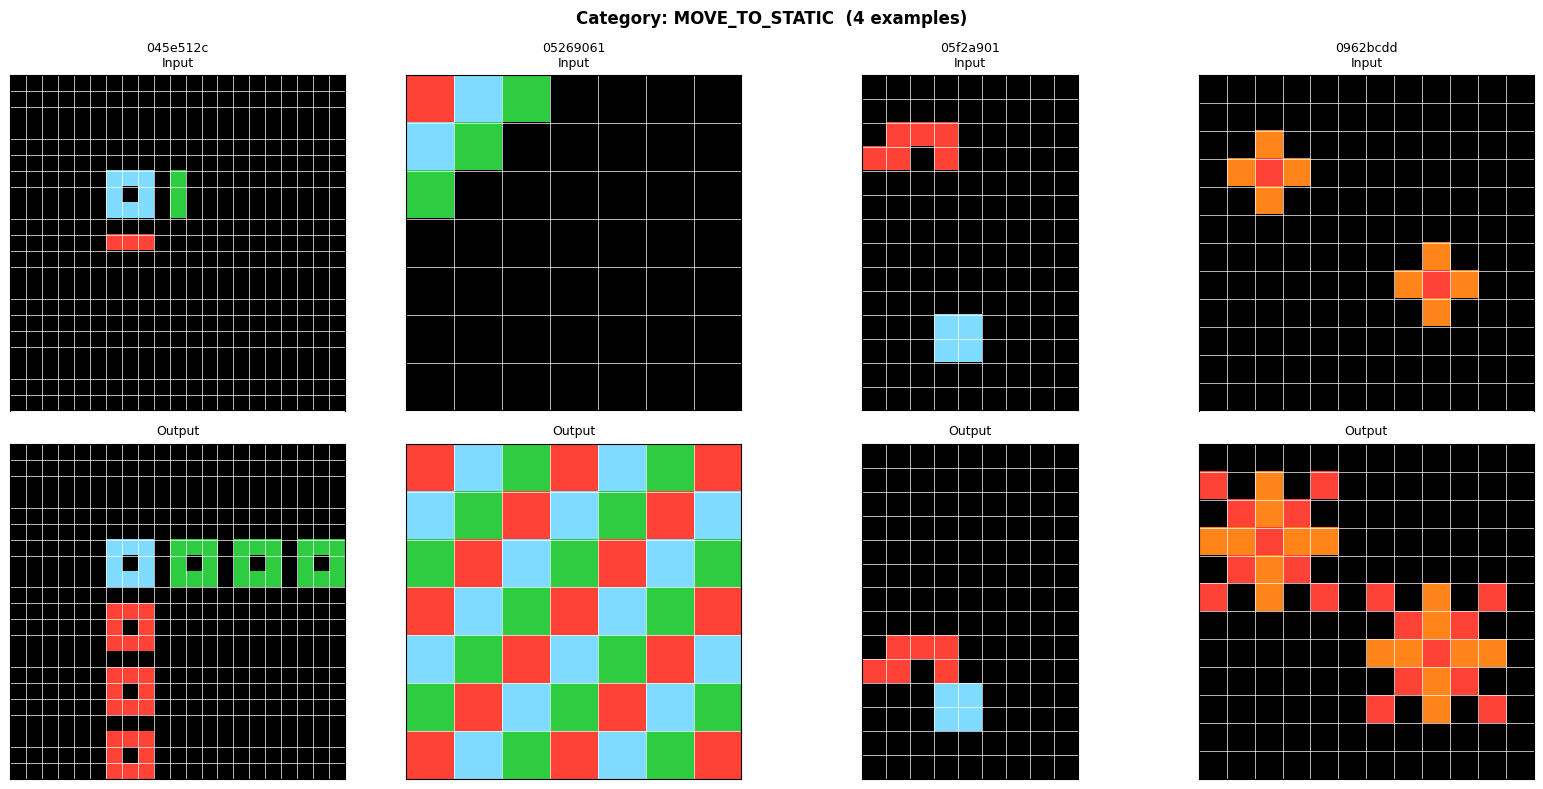

In [4]:
CATEGORY = 'MOVE_TO_STATIC'   # ← change this to any category name
N_SAMPLES = 4                 # number of tasks to show side by side

cat_tasks = by_tree[CATEGORY]
print(f'{CATEGORY}: {len(cat_tasks)} tasks total, showing {min(N_SAMPLES, len(cat_tasks))}')
fig = plot_category_sample(cat_tasks, CATEGORY, n=N_SAMPLES)
plt.show()

## 4. Step through a category one task at a time

Set `CATEGORY` (same as above) and `IDX` to the task index (0, 1, 2 …).  
Re-run the cell to advance through the list.  
Shows **all** train pairs + the test input.

Category : MOVE_TO_STATIC  (82 tasks)
Index    : 0  →  task ID: 045e512c
Train pairs: 3


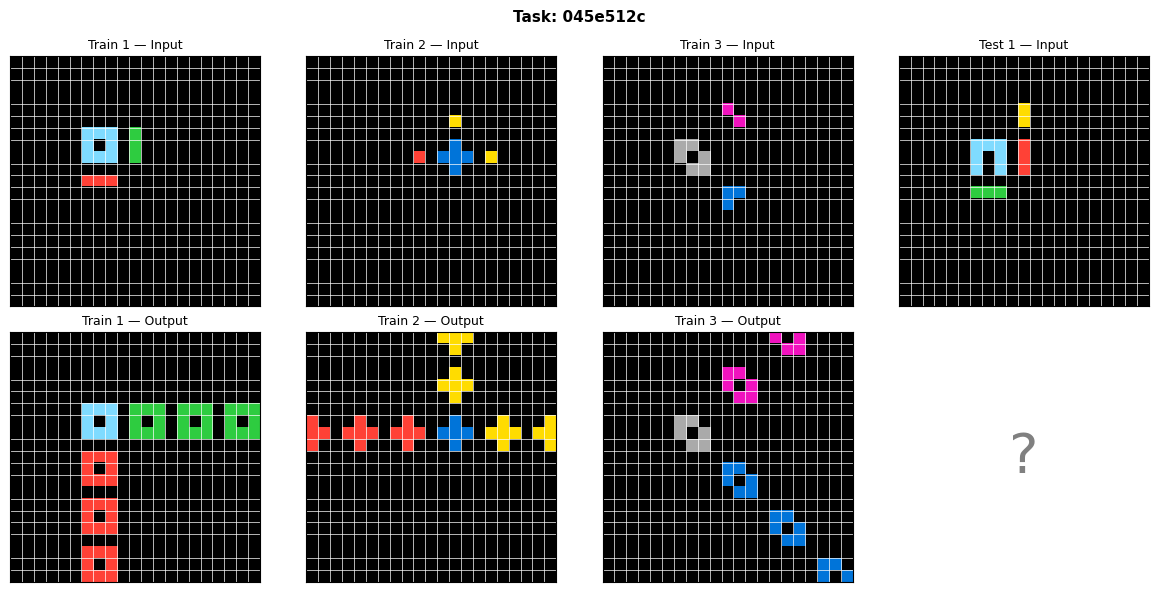

In [5]:
CATEGORY = 'MOVE_TO_STATIC'   # ← category to browse
IDX      = 0                  # ← index within category (0-based)

cat_tasks = by_tree[CATEGORY]
task = cat_tasks[IDX]
print(f'Category : {CATEGORY}  ({len(cat_tasks)} tasks)')
print(f'Index    : {IDX}  →  task ID: {task["task_id"]}')
print(f'Train pairs: {len(task["train"])}')
fig = plot_task(task)
plt.show()

## 5. Inspect a specific task by ID

Set `TASK_ID` to any 8-character task ID and re-run.

Task ID  : 007bbfb7
Category : TILE_ASSEMBLY
Train pairs: 5


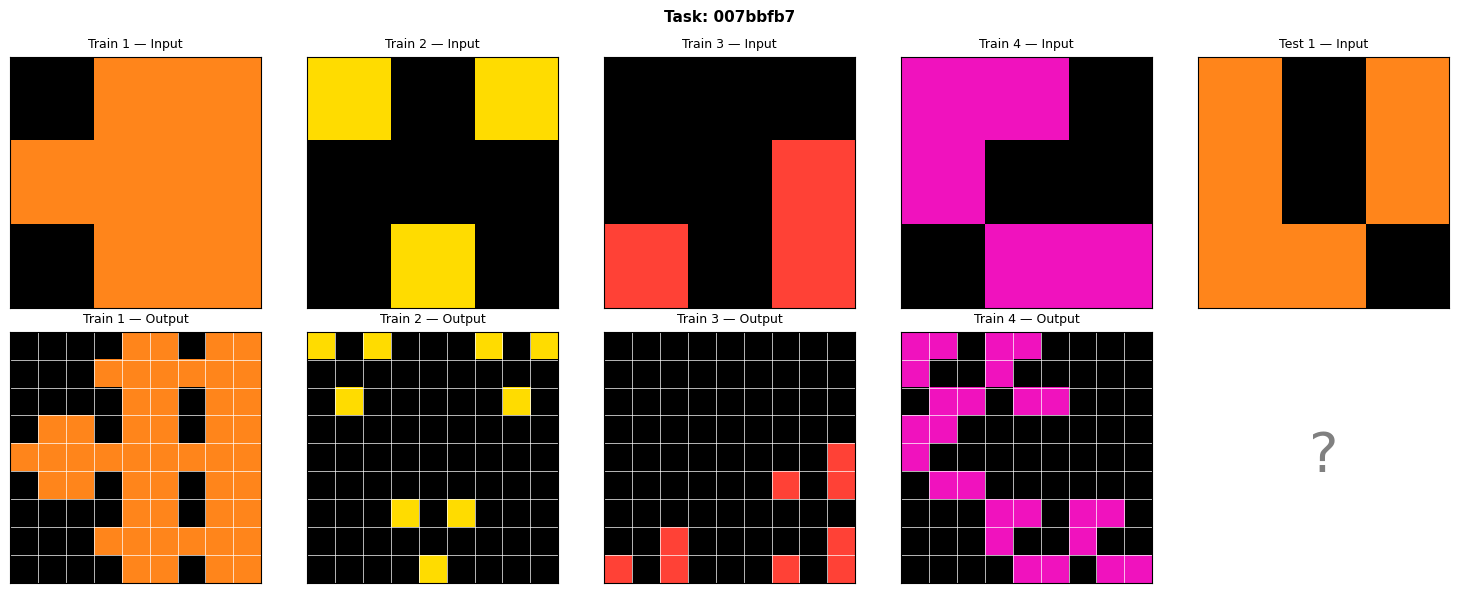

In [6]:
TASK_ID = '007bbfb7'   # ← change to any task ID

task = next(t for t in tasks if t['task_id'] == TASK_ID)
print(f'Task ID  : {task["task_id"]}')
print(f'Category : {task["tree_category"]}')
print(f'Train pairs: {len(task["train"])}')
fig = plot_task(task)
plt.show()

## 6. Quick-compare: all tasks in a category at once

Renders every task in the chosen category — useful for spotting sub-patterns.

COLOUR_REMOVAL: 27 tasks
  1a07d186


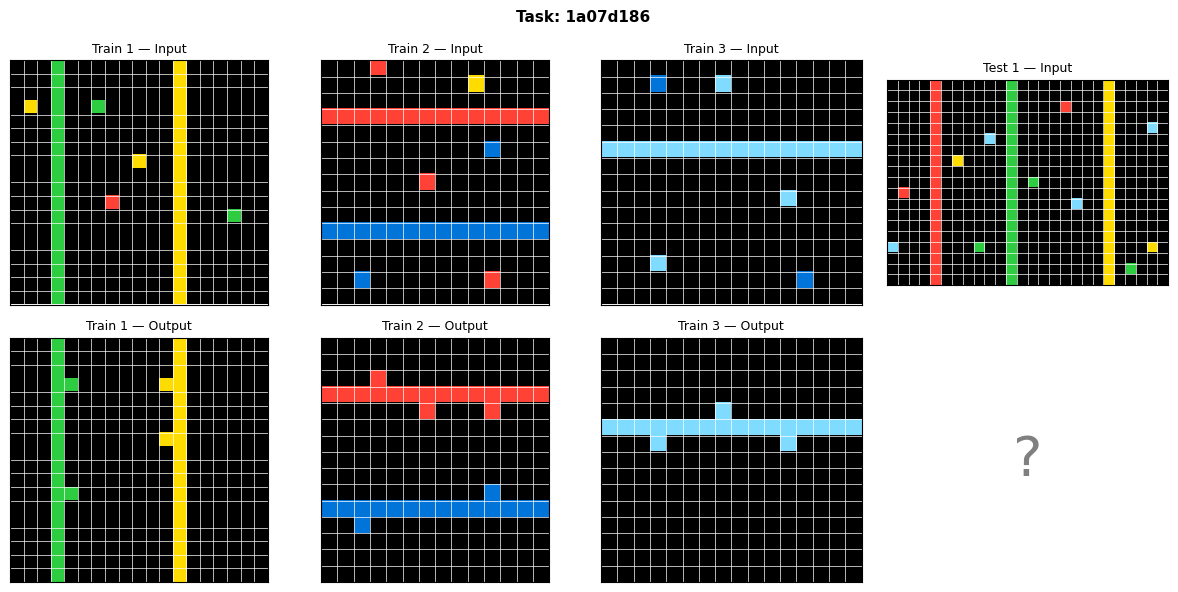

  1f0c79e5


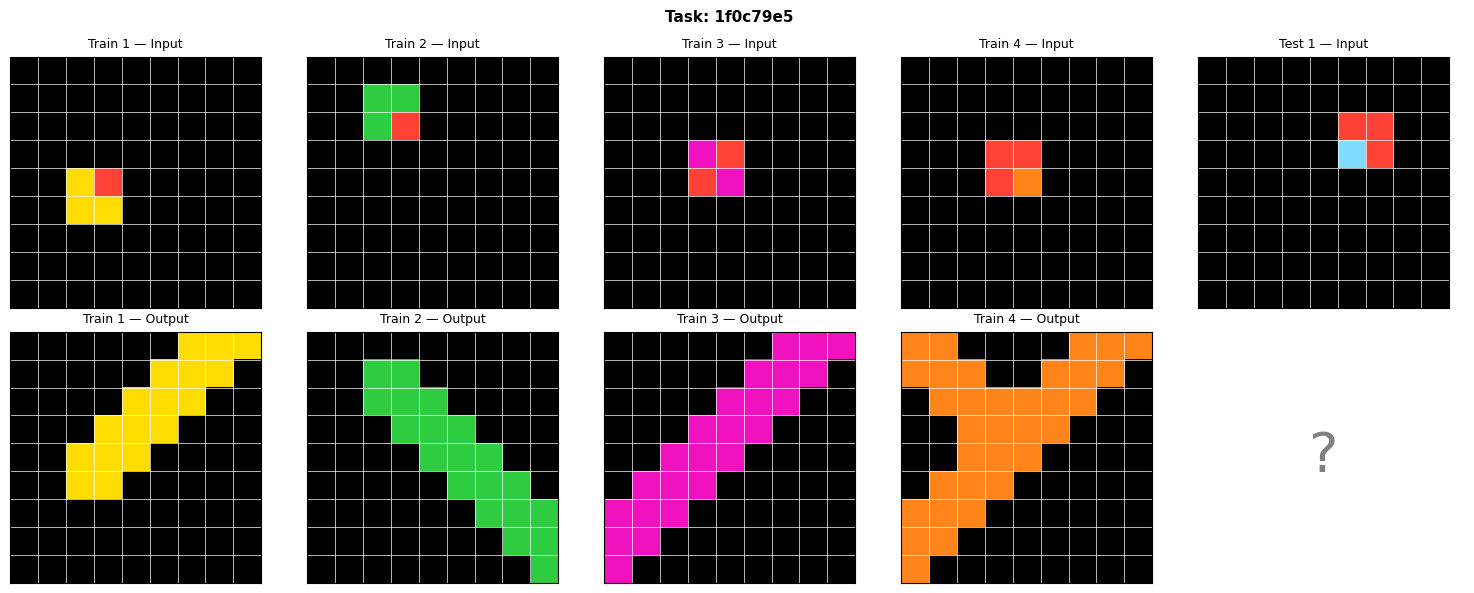

  31aa019c


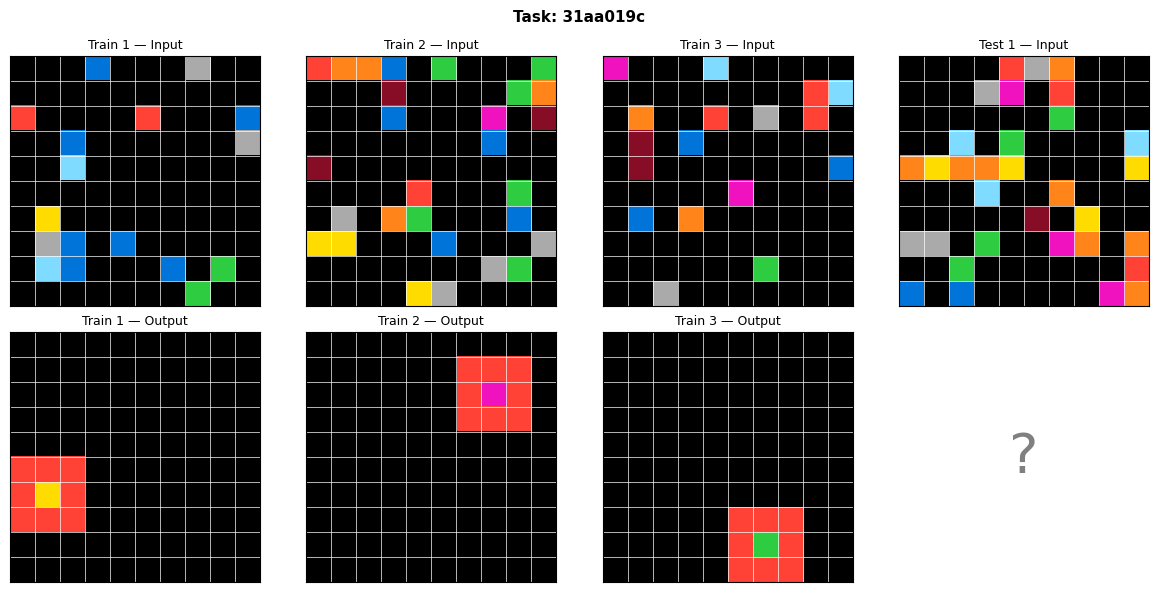

  321b1fc6


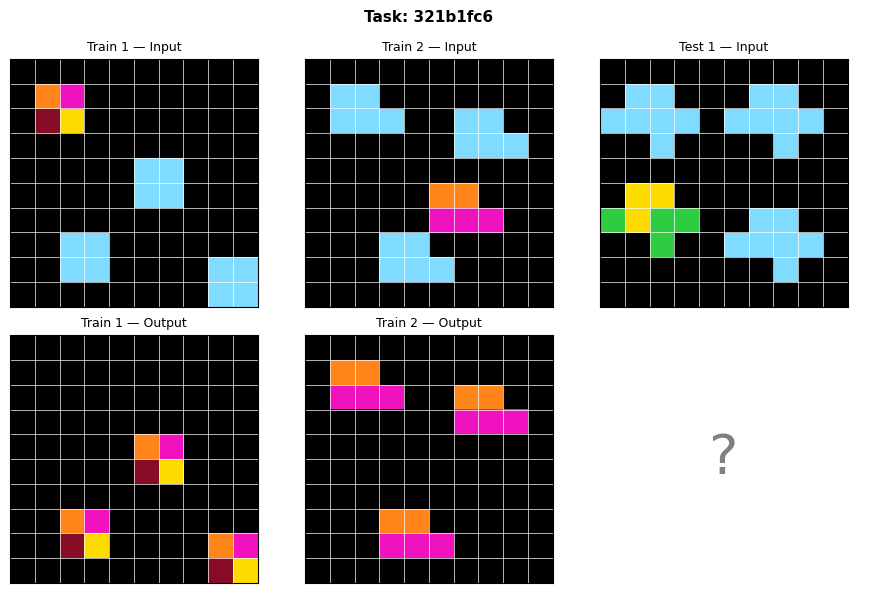

  3345333e


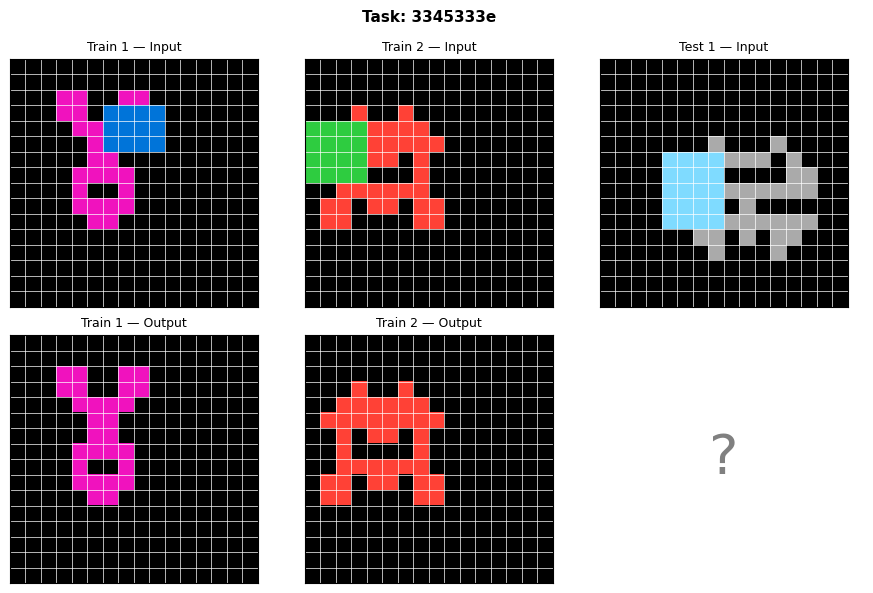

  3631a71a


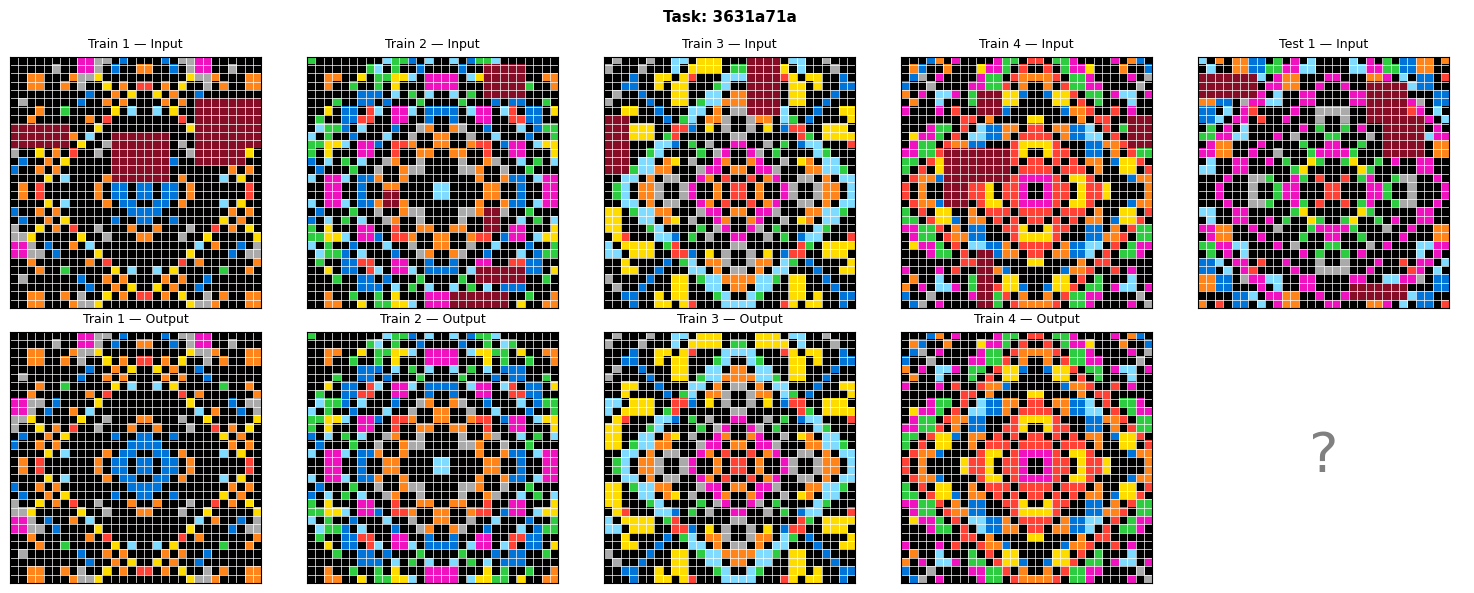

  363442ee


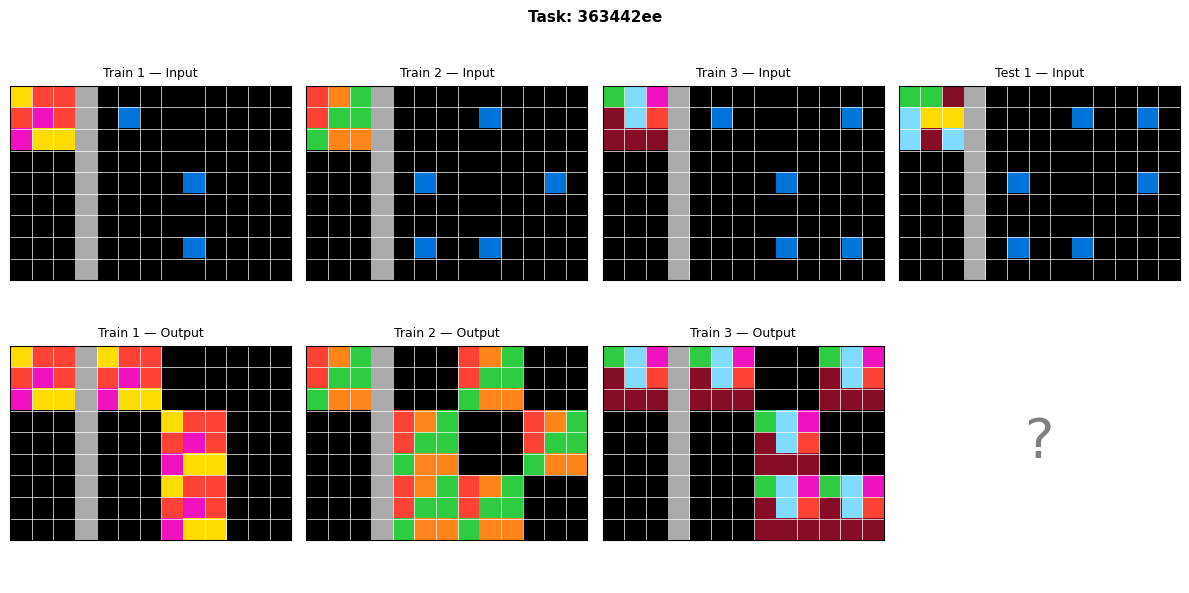

  5582e5ca


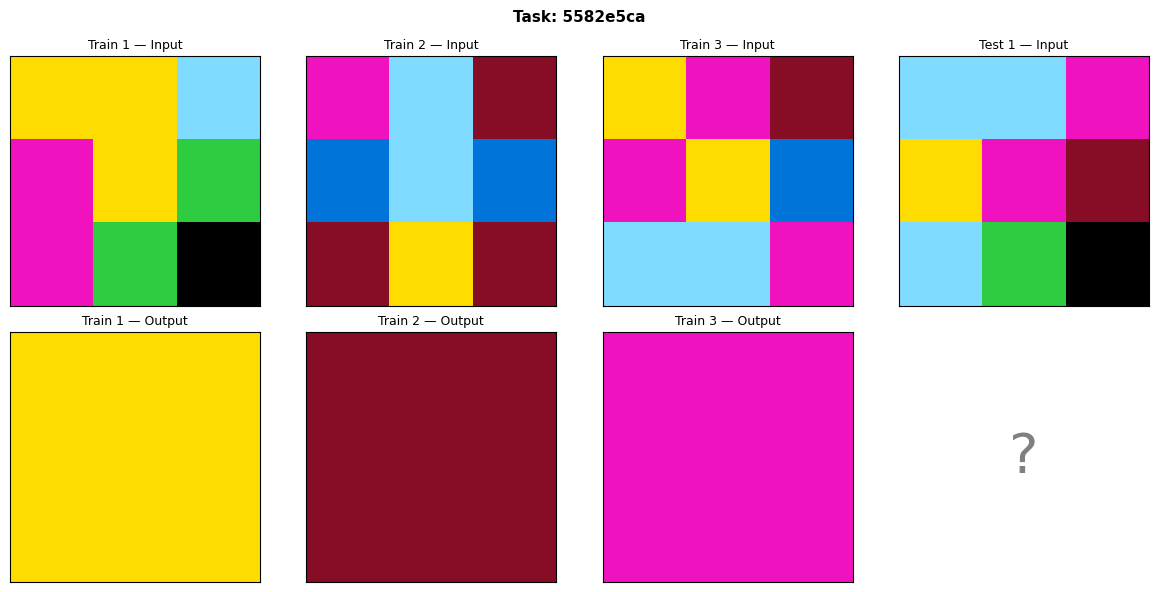

  63613498


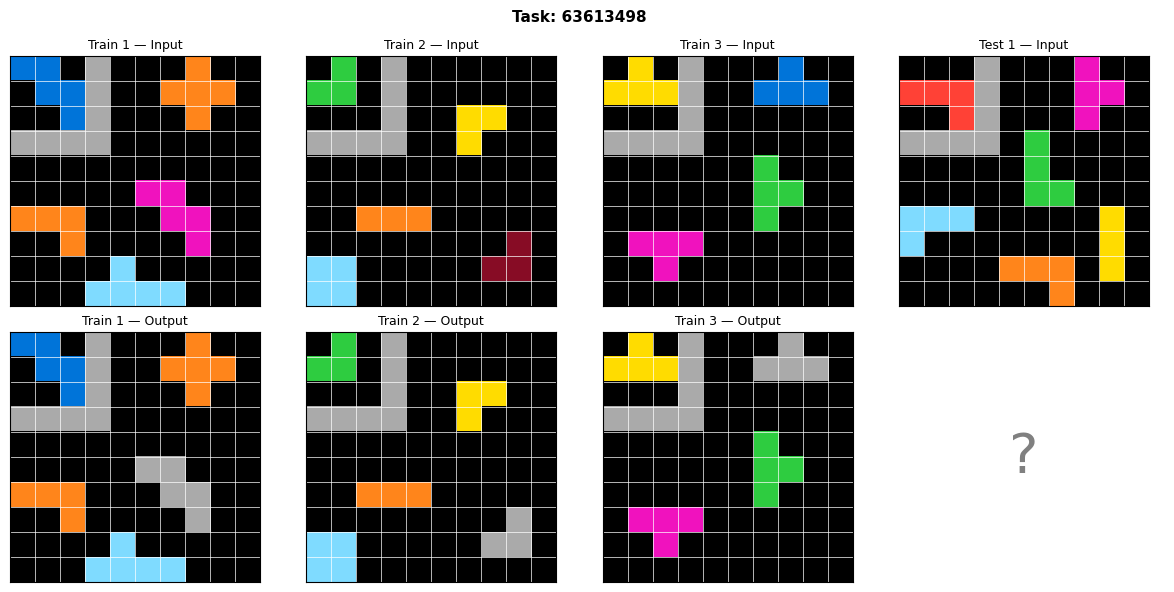

  6cdd2623


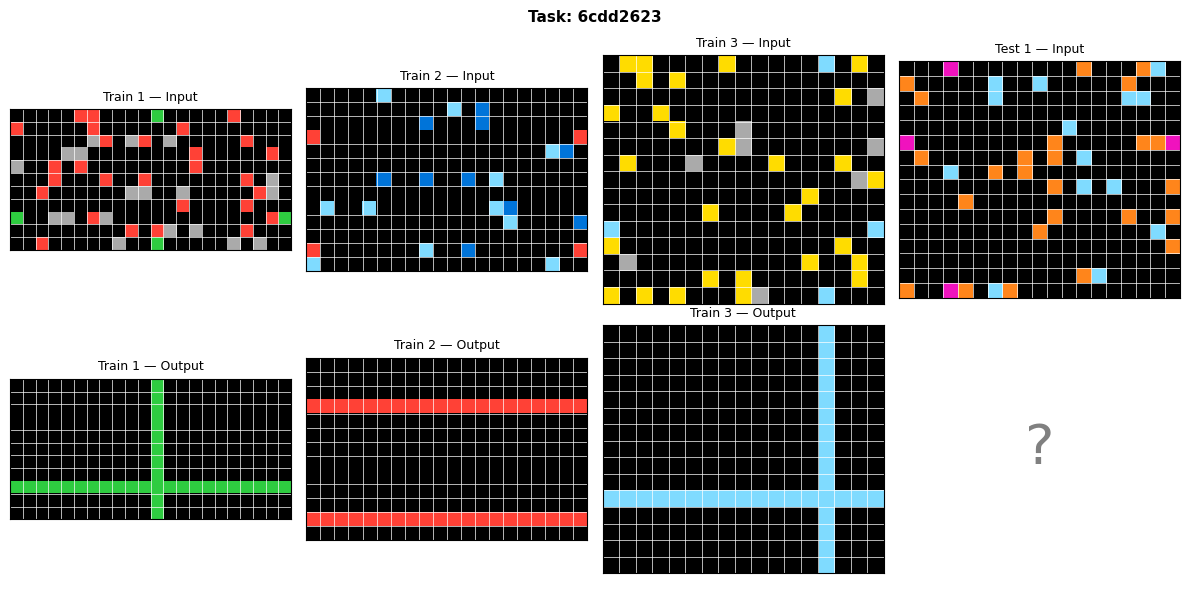

  7e0986d6


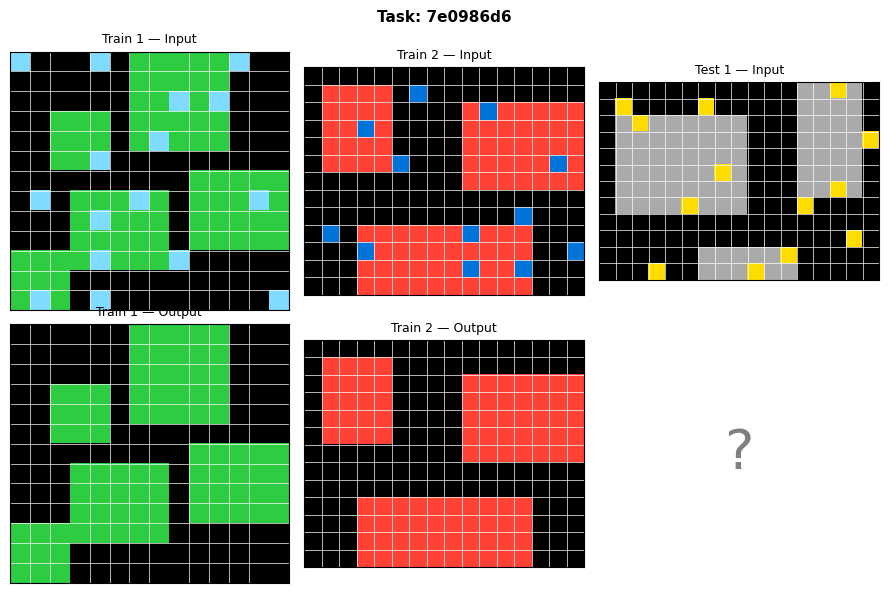

  88a10436


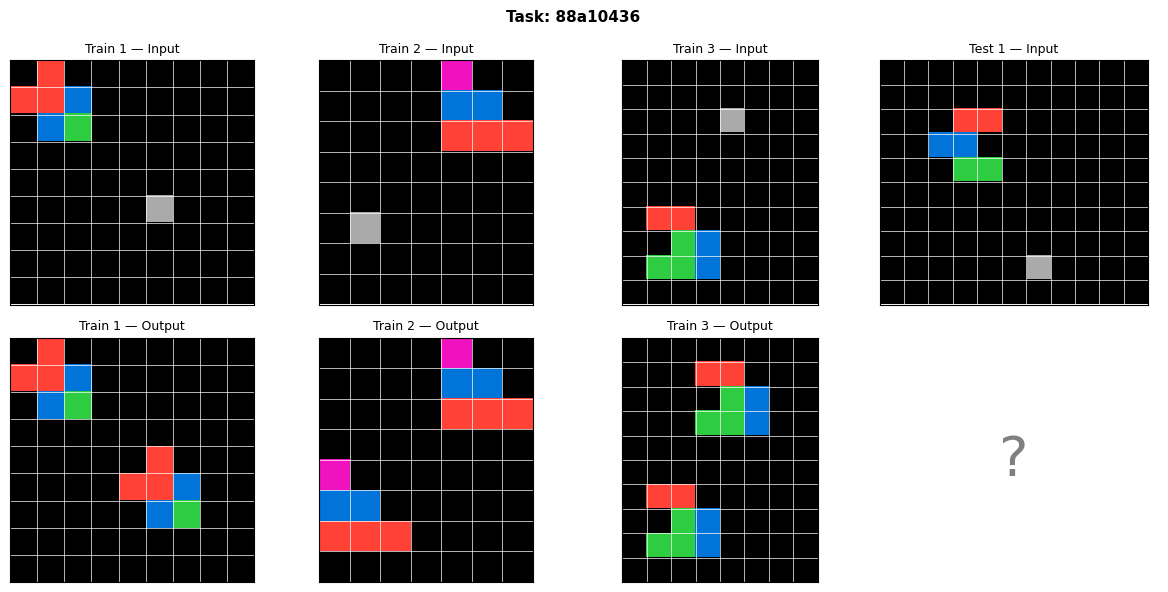

  91714a58


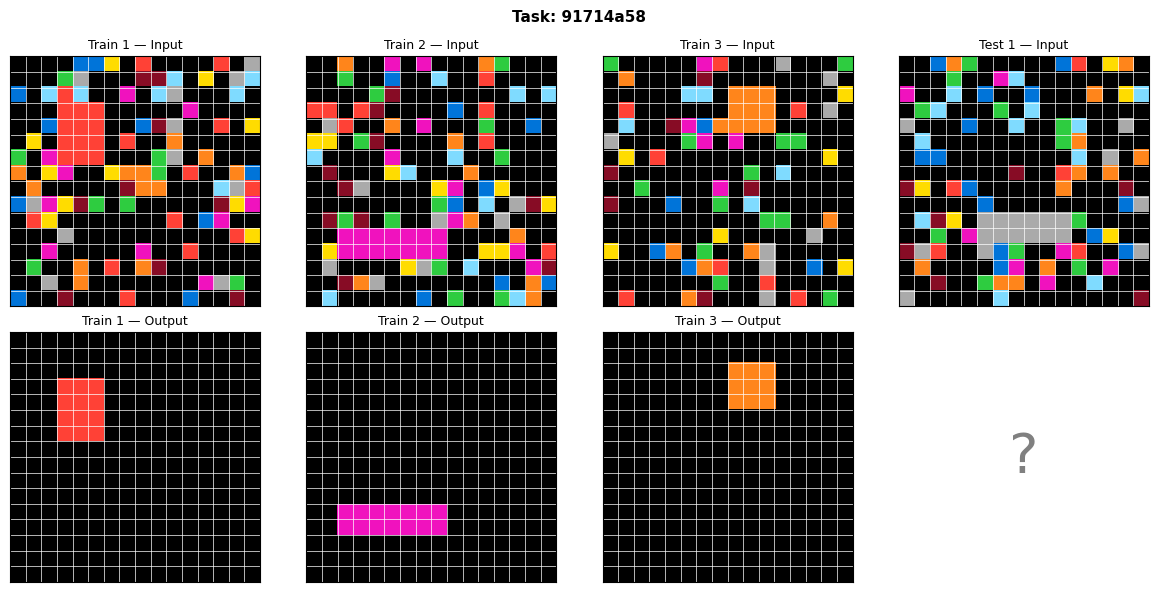

  a78176bb


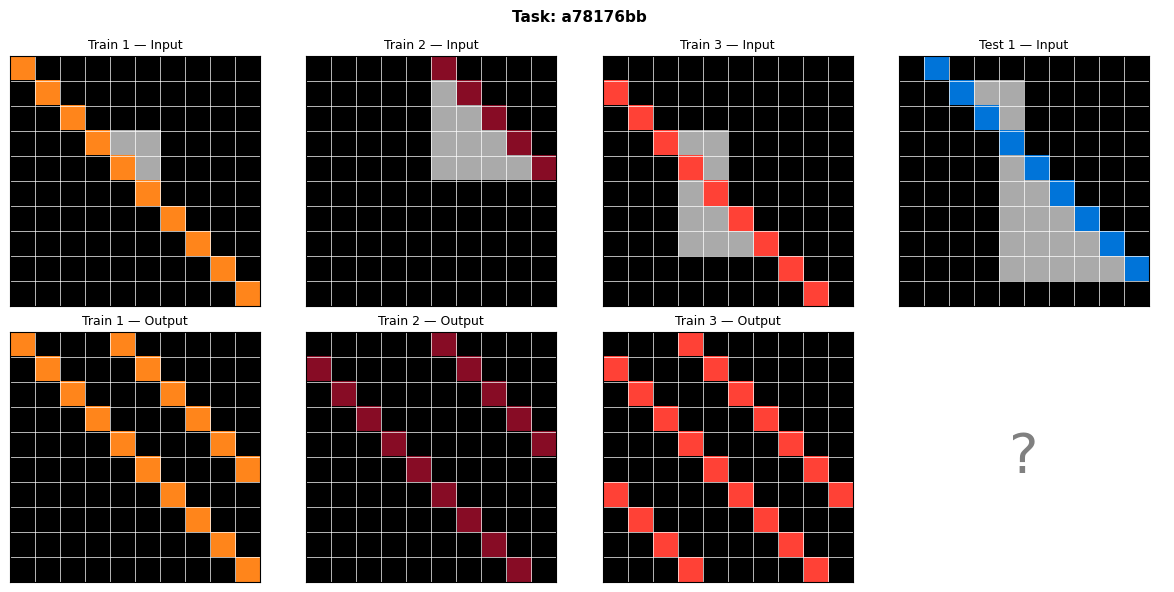

  aabf363d


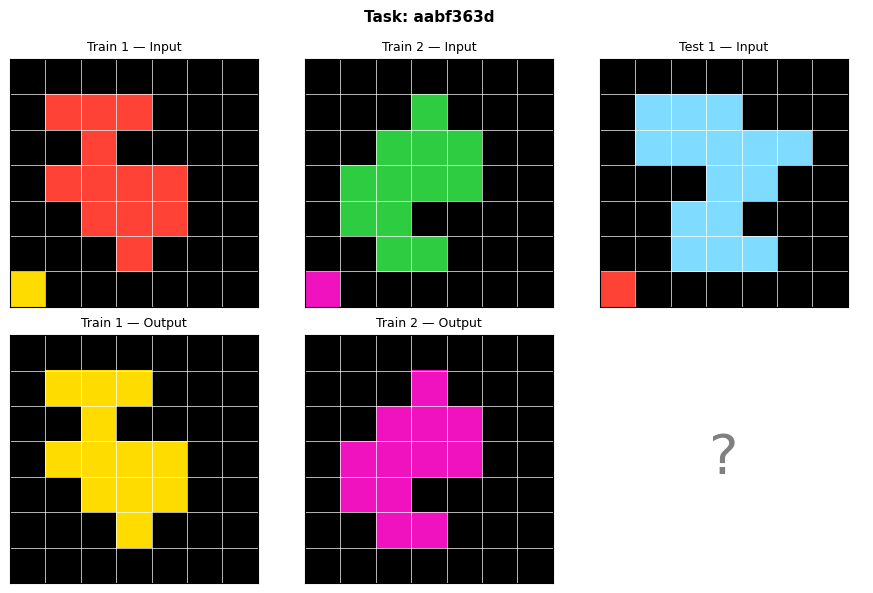

  b548a754


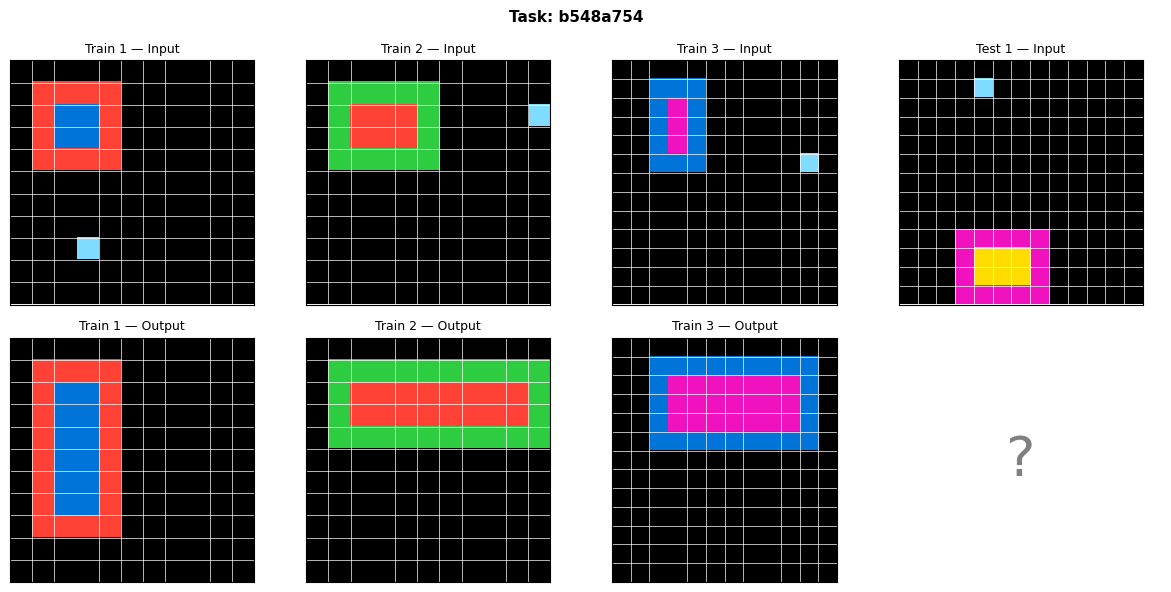

  b8825c91


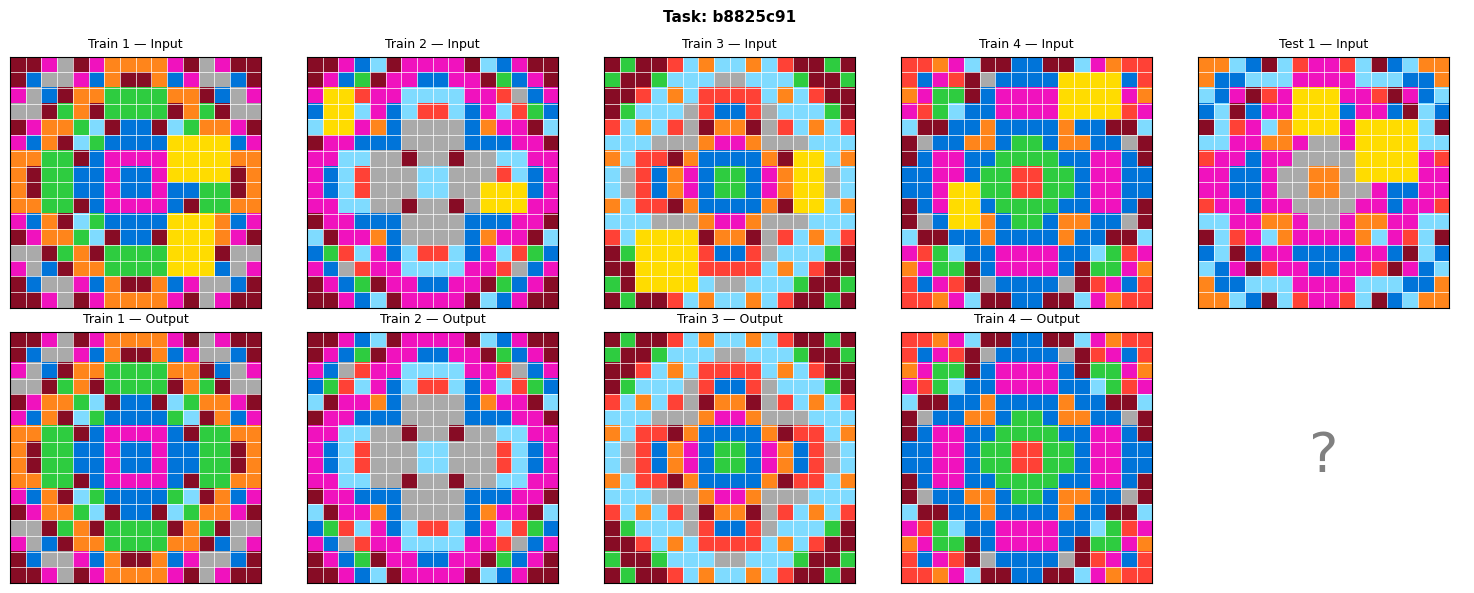

  c9f8e694


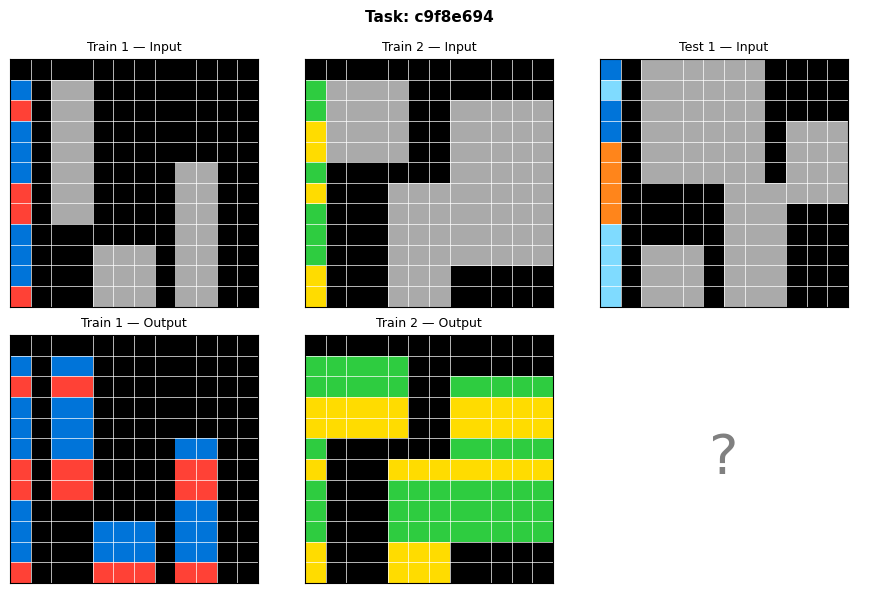

  caa06a1f


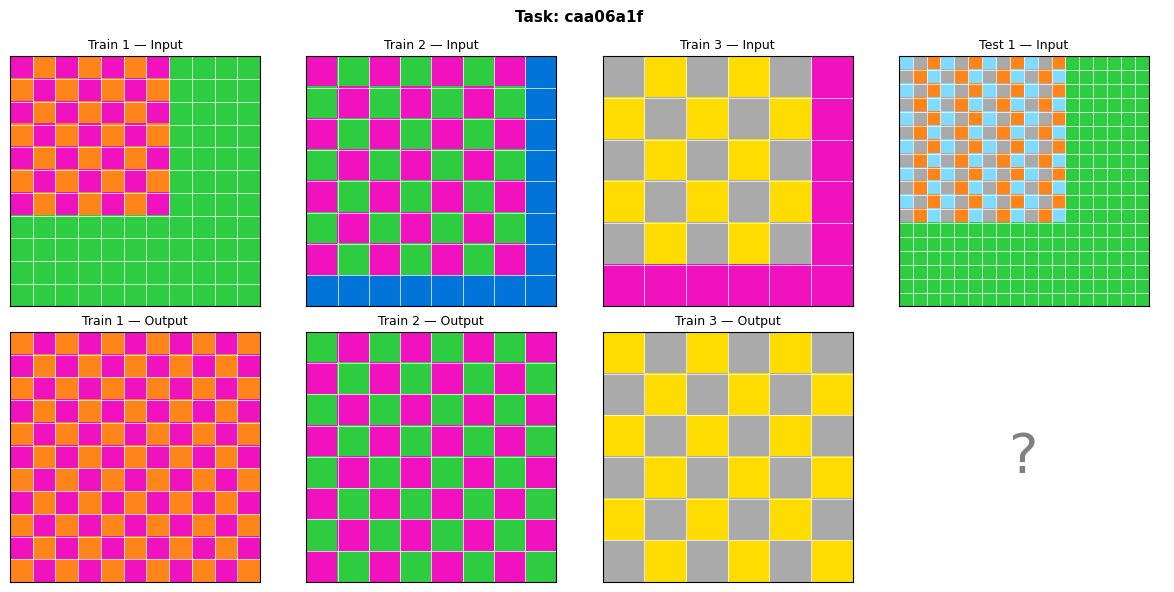

  d23f8c26


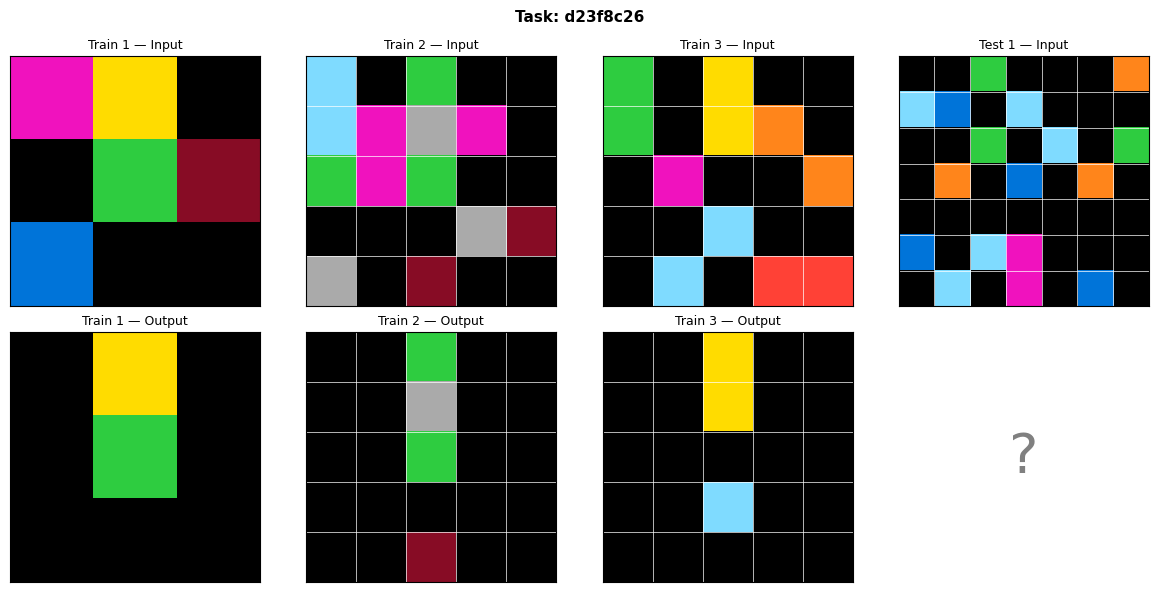

  d687bc17


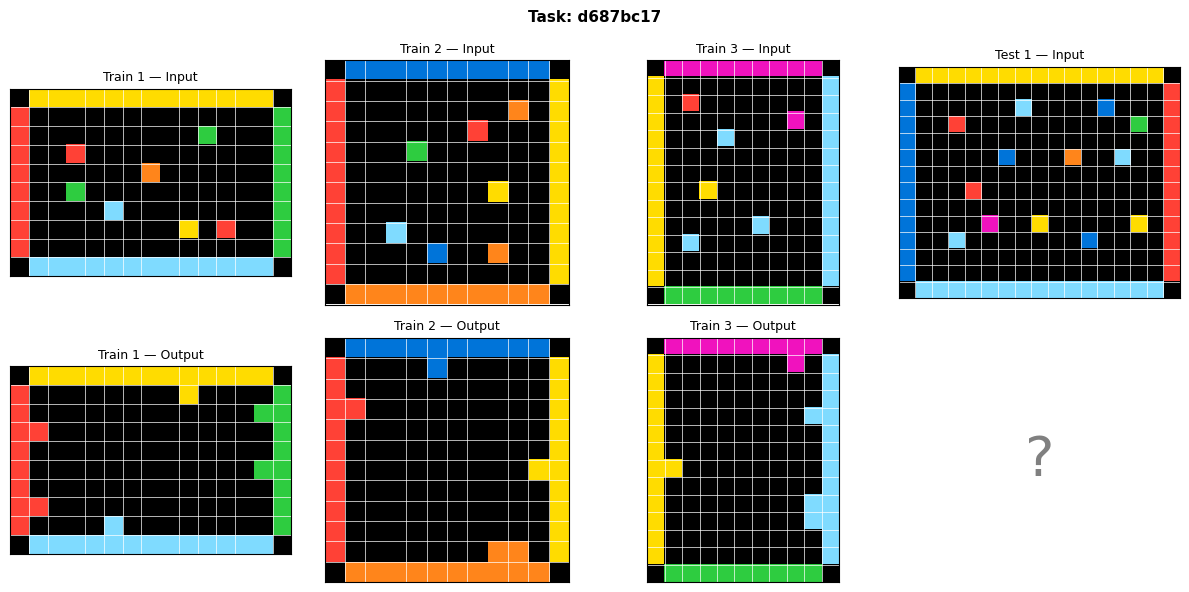

  d89b689b


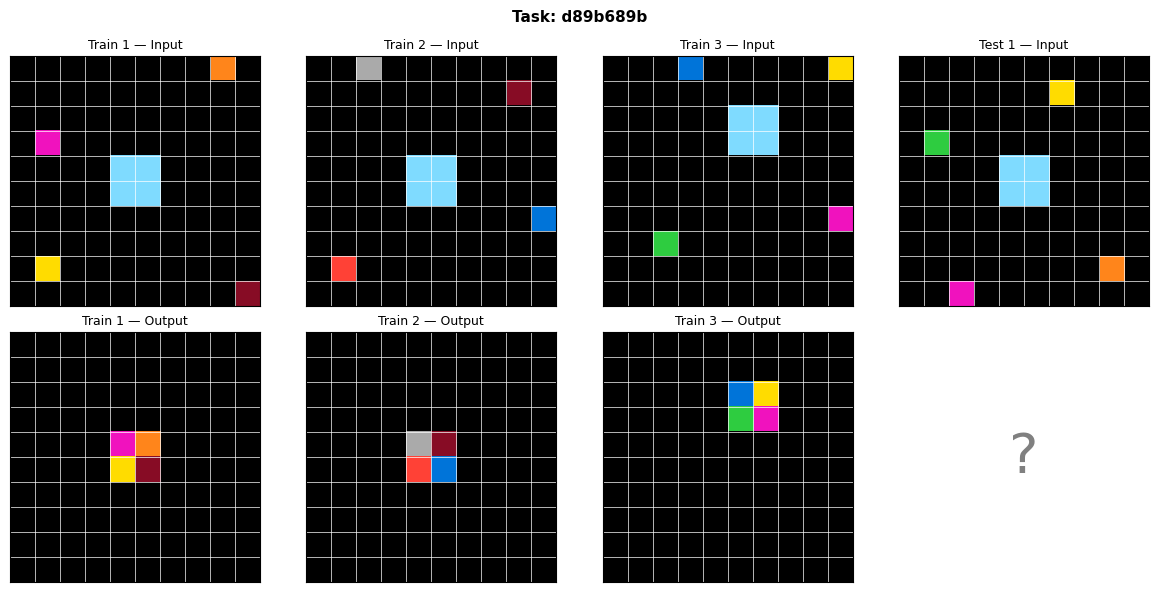

  ddf7fa4f


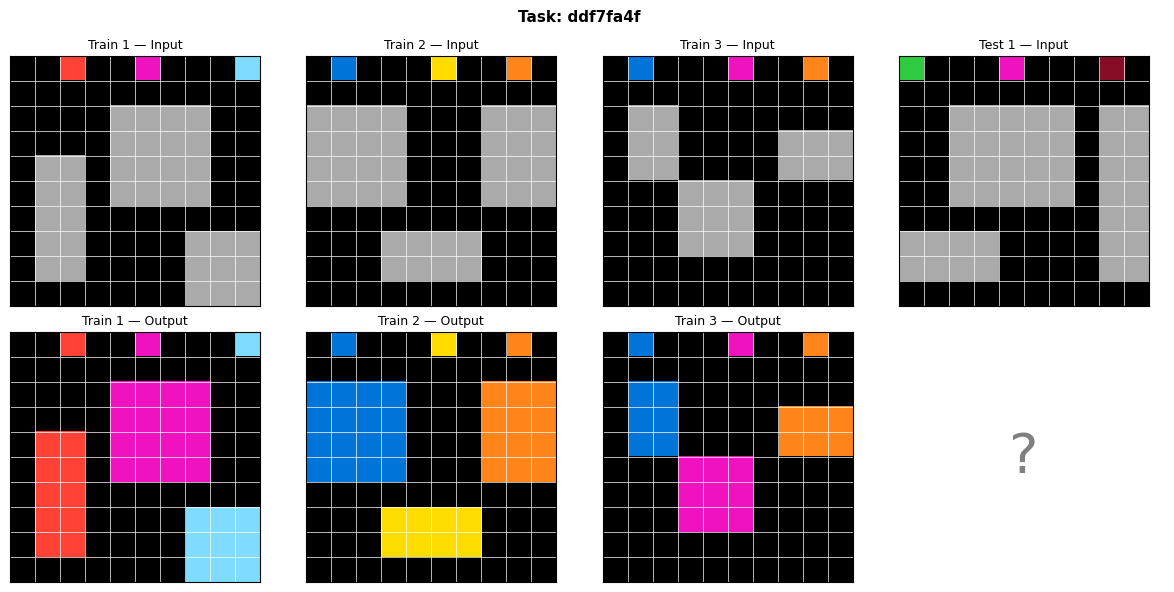

  e26a3af2


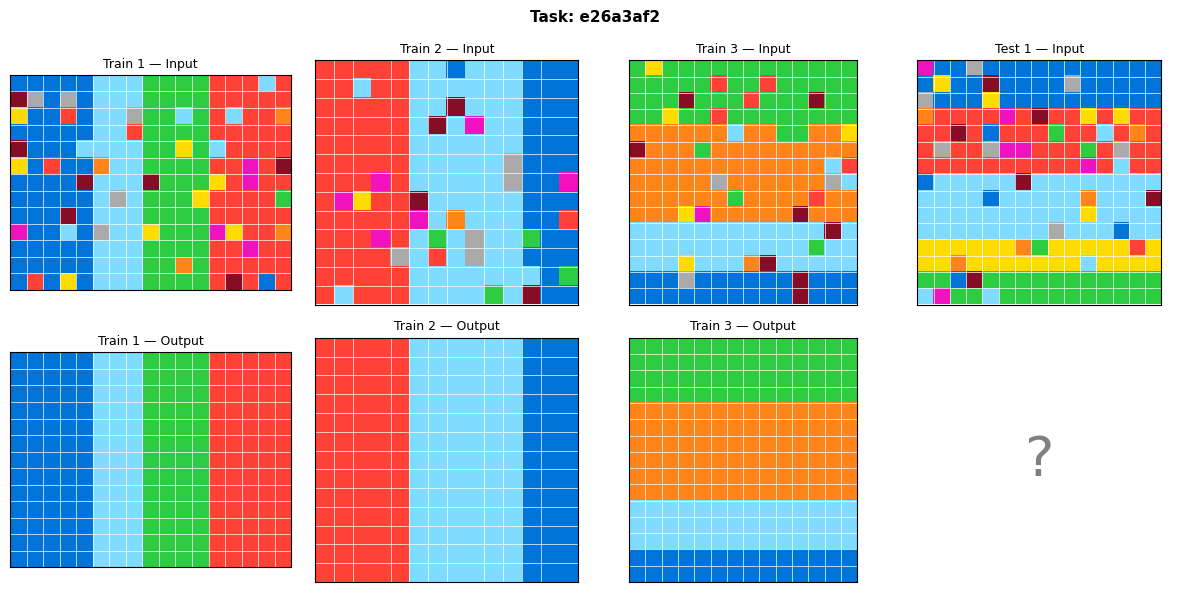

  e48d4e1a


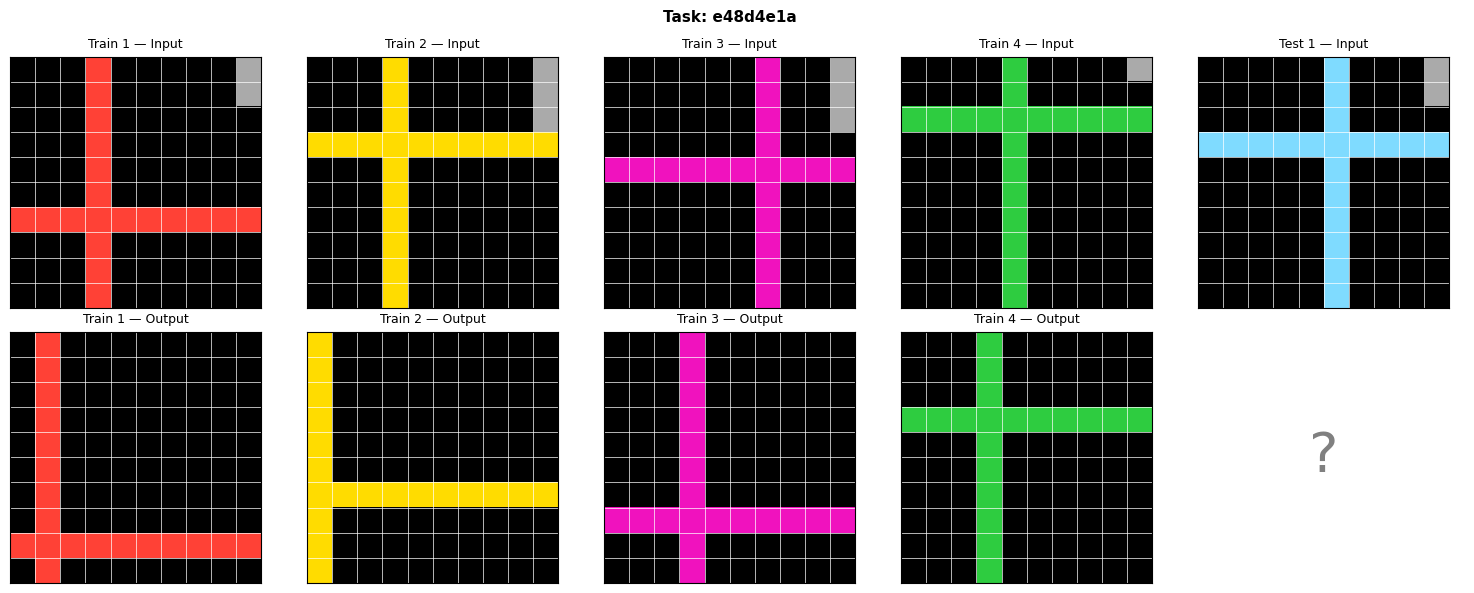

  e76a88a6


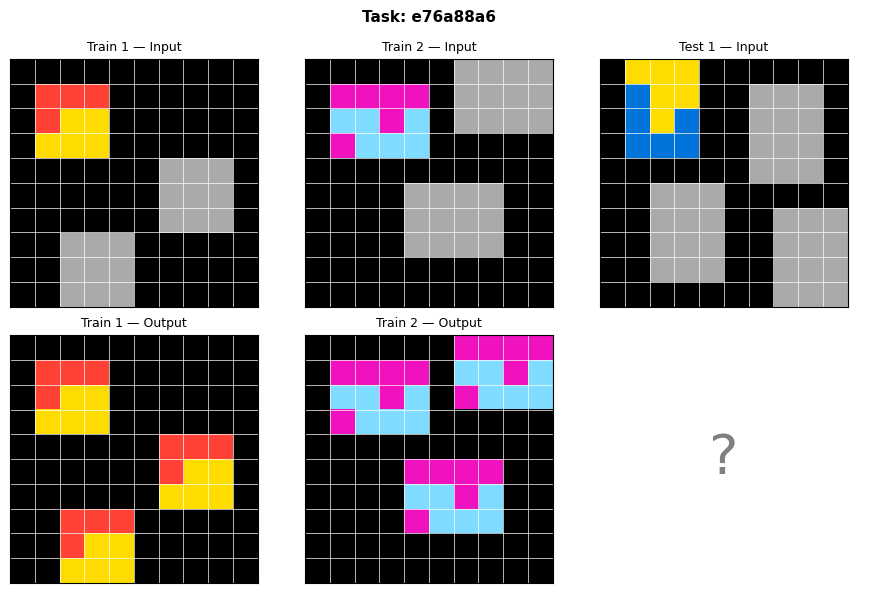

  f76d97a5


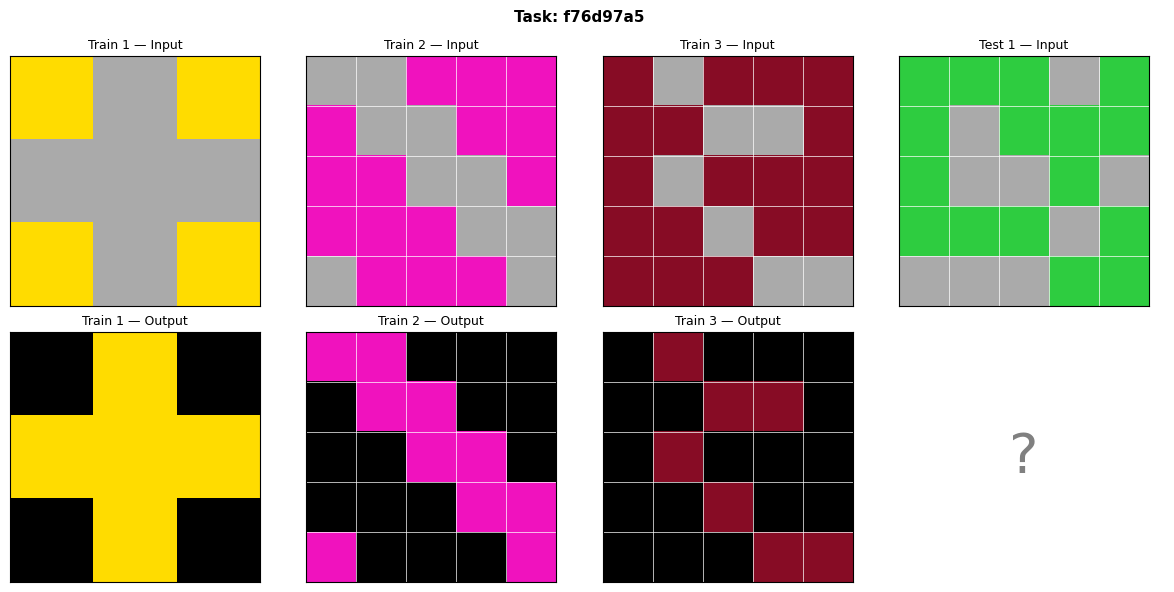

In [7]:
CATEGORY = 'COLOUR_REMOVAL'   # ← category to dump entirely

cat_tasks = by_tree[CATEGORY]
print(f'{CATEGORY}: {len(cat_tasks)} tasks')
for task in cat_tasks:
    print(f'  {task["task_id"]}')
    fig = plot_task(task)
    plt.show()

## 7. FILL_REGIONS — sub-groups by delta profile

Each FILL_REGIONS task is classified by what its input→output delta looks like:

| Type | gained | lost | recoloured | new colours | Meaning |
|------|--------|------|------------|-------------|---------|
| A | > 0 | 0 | 0 | 1 | Pure fill: zeros filled with one new colour |
| B | > 0 | 0 | 0 | > 1 | Pure fill: zeros filled with multiple new colours |
| C | > 0 | 0 | > 0 | any | Fill AND recolour existing cells |
| D | > 0 | > 0 | any | any | Fill and erase cells |
| E | 0 | 0 | > 0 | any | Recolour only (no zero change) |

Run the **three cells below** in order: (1) build the groups, (2) browse one task at a time, (3) overview grid.

In [ ]:
# ── 7a. Build FILL_REGIONS sub-groups ────────────────────────────────────────
# Run this cell first; the two cells below depend on `groups`.

import sys, os
from pathlib import Path

_here = Path(os.getcwd())
PROJECT_ROOT = _here.parent if _here.name == 'notebooks' else _here
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from scripts.solvers import load_task as sol_load_task, task_delta

def _delta_type(d):
    g, lo, r, nc = d['zeros_gained'], d['zeros_lost'], d['recoloured'], len(d['new_colours'])
    if g > 0 and lo == 0 and r == 0 and nc == 1: return 'A — pure fill, 1 new colour'
    if g > 0 and lo == 0 and r == 0 and nc > 1:  return 'B — pure fill, multiple new colours'
    if g > 0 and lo == 0 and r > 0:               return 'C — fill + recolour'
    if g > 0 and lo > 0:                          return 'D — fill + erase'
    if g == 0 and r > 0:                          return 'E — recolour only'
    return 'F — other'

fill_tasks = by_tree['FILL_REGIONS']
groups = {}
for task in fill_tasks:
    st = sol_load_task(task['task_id'])
    d  = task_delta(st)
    t  = _delta_type(d)
    task['_delta'] = d
    task['_dtype'] = t
    groups.setdefault(t, []).append(task)

print(f'FILL_REGIONS: {len(fill_tasks)} tasks → {len(groups)} delta types\n')
for gname, gtasks in sorted(groups.items()):
    ids = '  '.join(t['task_id'] for t in gtasks[:6])
    suffix = '  ...' if len(gtasks) > 6 else ''
    print(f'  {gname}  ({len(gtasks)} tasks)')
    print(f'    {ids}{suffix}')

In [ ]:
# ── 7b. Browse one task at a time within a delta type ────────────────────────
# Change DTYPE and IDX, then re-run.

DTYPE = 'A — pure fill, 1 new colour'   # ← type label from the cell above
IDX   = 0                                # ← index within that group (0-based)

gtasks = groups[DTYPE]
task   = gtasks[IDX]
d      = task['_delta']

print(f'Type  : {DTYPE}  ({len(gtasks)} tasks)')
print(f'Index : {IDX}  →  {task["task_id"]}')
print(f'Delta : gained={d["zeros_gained"]}  lost={d["zeros_lost"]}  '
      f'recoloured={d["recoloured"]}  new_colours={d["new_colours"]}')
fig = plot_task(task)
plt.show()

In [ ]:
# ── 7c. Overview: one representative task per delta type ─────────────────────

ARC_COLORS = [
    '#000000','#0074D9','#FF4136','#2ECC40','#FFDC00',
    '#AAAAAA','#F012BE','#FF851B','#7FDBFF','#870C25',
]
_cmap = plt.matplotlib.colors.ListedColormap(ARC_COLORS)
_norm = plt.matplotlib.colors.BoundaryNorm(range(11), 10)

def _show_pair(ax_in, ax_out, pair, title_in, title_out):
    for ax, grid, title in [(ax_in, pair['input'], title_in),
                             (ax_out, pair['output'], title_out)]:
        ax.imshow(np.array(grid, dtype=np.uint8), cmap=_cmap, norm=_norm,
                  interpolation='nearest', vmin=0, vmax=9)
        ax.set_title(title, fontsize=7)
        ax.axis('off')

type_order = sorted(groups.keys())
n = len(type_order)
fig, axes = plt.subplots(n, 2, figsize=(7, n * 3.2))
if n == 1:
    axes = [axes]

for row, dtype in enumerate(type_order):
    rep  = groups[dtype][0]
    pair = rep['train'][0]
    d    = rep['_delta']
    _show_pair(
        axes[row][0], axes[row][1], pair,
        title_in  = f'{dtype}\n{rep["task_id"]} — input',
        title_out = f'output  '
                    f'(gained={d["zeros_gained"]} recol={d["recoloured"]} '
                    f'new={d["new_colours"]})',
    )

plt.tight_layout()
plt.show()